In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
train_df = pd.read_csv('train.csv', dtype={'StateHoliday': str})
store_df = pd.read_csv('store.csv')
print(f"Train shape: {train_df.shape}")
print(f"Store shape: {store_df.shape}")
print(f"\nFirst few rows:")
print(train_df.head())
pd.set_option('display.max_columns',None)
train_df['Date'] = pd.to_datetime(train_df['Date'])
print(f'\nDate range: {train_df.min()} to {train_df.max()}')
print(f'\nDuration: {(train_df['Date'].max() - train_df['Date'].min()).days}')
print(f'Number of stores: {train_df['Store'].nunique()}')
print(f'total observation {len(train_df):,}')
print(f'\nColumn info: {train_df.info()}')

Train shape: (1017209, 9)
Store shape: (1115, 10)

First few rows:
   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
3      4          5  2015-07-31  13995       1498     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   

   SchoolHoliday  
0              1  
1              1  
2              1  
3              1  
4              1  

Date range: Store                              1
DayOfWeek                          1
Date             2013-01-01 00:00:00
Sales                              0
Customers                          0
Open                               0
Promo                              0
StateHoliday                       0
SchoolHoliday                      

In [28]:
daily_sales = train_df.groupby('Date')['Sales'].agg(['sum','mean','count']).reset_index()
daily_sales.columns = ['Date','TotalSales','AvgSales','StoresOpen']
print("=== DAILY SALES SUMMARY ===")
print(daily_sales.head(10))
print(f"\nStats:")
print(daily_sales.describe())


=== DAILY SALES SUMMARY ===
        Date  TotalSales     AvgSales  StoresOpen
0 2013-01-01       97235    87.284560        1114
1 2013-01-02     6949829  6233.030493        1115
2 2013-01-03     6347820  5693.112108        1115
3 2013-01-04     6638954  5954.218834        1115
4 2013-01-05     5951593  5337.751570        1115
5 2013-01-06      143904   129.061883        1115
6 2013-01-07    10826848  9710.177578        1115
7 2013-01-08     8749437  7847.028700        1115
8 2013-01-09     7746603  6947.626009        1115
9 2013-01-10     7751485  6952.004484        1115

Stats:
                      Date    TotalSales      AvgSales   StoresOpen
count                  942  9.420000e+02    942.000000   942.000000
mean   2014-04-16 12:00:00  6.234799e+06   5782.702036  1079.839703
min    2013-01-01 00:00:00  9.723500e+04     87.284560   935.000000
25%    2013-08-24 06:00:00  5.675832e+06   5321.408512  1115.000000
50%    2014-04-16 12:00:00  6.580354e+06   6036.153617  1115.000000
75%   

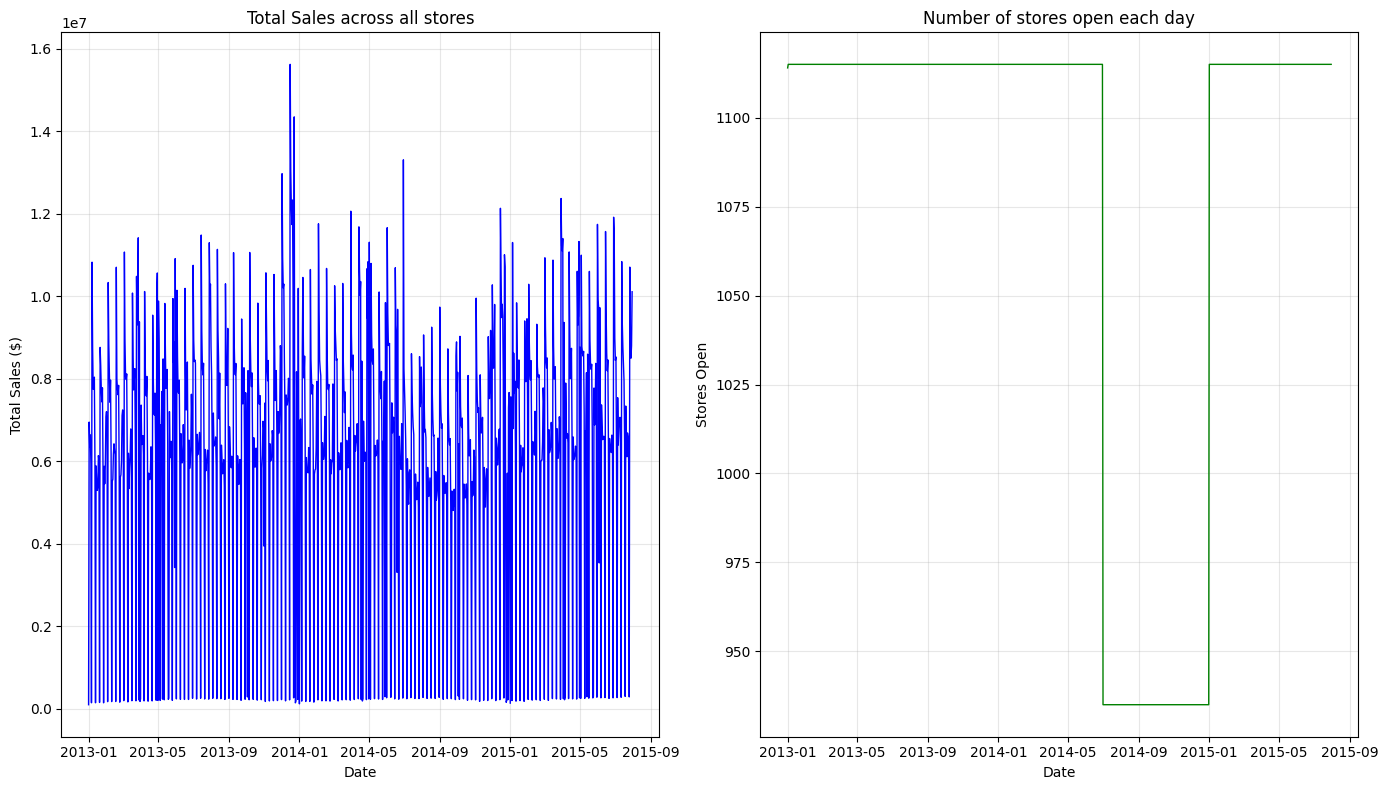

In [38]:
fig,axes = plt.subplots(1,2,figsize = (14,8))

axes[0].plot(daily_sales['Date'],daily_sales['TotalSales'],linewidth = 1,color = 'blue')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Total Sales ($)')
axes[0].set_title('Total Sales across all stores')
axes[0].grid(alpha=0.3)

axes[1].plot(daily_sales['Date'],daily_sales['StoresOpen'],linewidth = 1 ,color = 'green')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Stores Open')
axes[1].set_title('Number of stores open each day')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

=== Weekly Seasonality ===
DayName
Monday       7828.585262
Tuesday      7022.591726
Wednesday    6561.618318
Thursday     6265.341800
Friday       6721.988769
Saturday     5847.518765
Sunday        205.592506
Name: AvgSales, dtype: float64


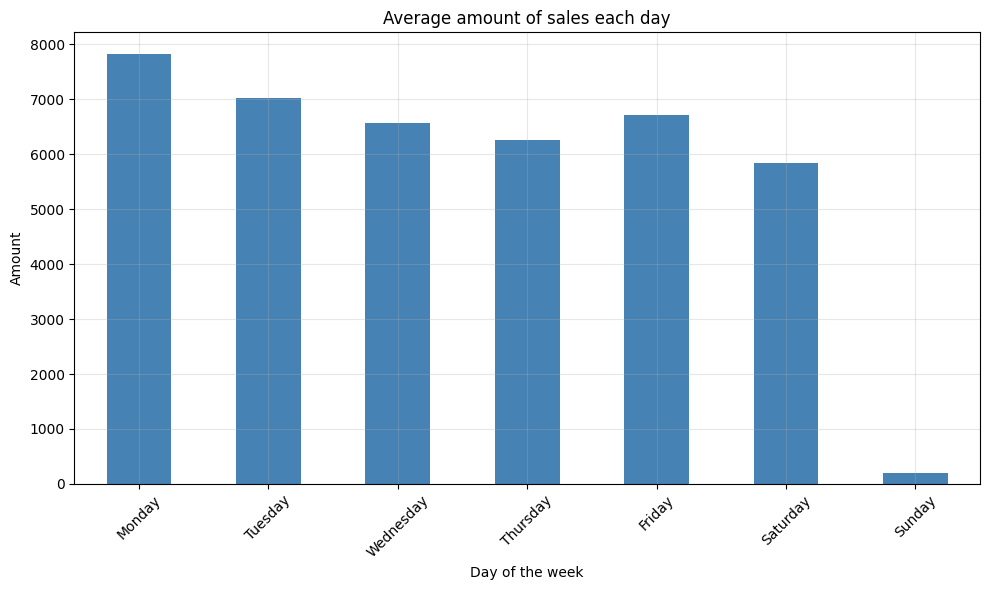

In [66]:
daily_sales['DayOfWeek'] = daily_sales['Date'].dt.dayofweek
daily_sales['DayName'] = daily_sales['Date'].dt.day_name()

weekly_patern = daily_sales.groupby('DayName')['AvgSales'].mean().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
print('=== Weekly Seasonality ===')
print(weekly_patern)

fig,ax = plt.subplots(figsize = (10, 6))

weekly_patern.plot(kind = 'bar',ax=ax,color = 'steelblue')
ax.set_xlabel('Day of the week')
ax.set_ylabel('Amount')
ax.set_title('Average amount of sales each day')
ax.grid(alpha = 0.3)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [81]:
train_full = train.merge(store,on='Store',how='left')
print('=== merged data ===')
print('shape of the merged data: ',train_full.shape)
print('new columns: ',train_full.columns.tolist())
print('first few rows: ')
print(train_full.head())

print('=== store types ===')
print(train_full['StoreType'].value_counts())
print('Average sales by each store')
print(train_full.groupby('StoreType')['Sales'].mean().sort_values(ascending = False))

print('Check if there are any missing data')
missing = train_full.isnull().sum()
print(missing[missing>0])

=== merged data ===
shape of the merged data:  (1017209, 18)
new columns:  ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']
first few rows: 
   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
3      4          5  2015-07-31  13995       1498     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   

   SchoolHoliday StoreType Assortment  CompetitionDistance  \
0              1         c          a               1270.0   
1              1         a        

In [106]:
print('closed days of week: ')
print(train_full[train_full['Open'] == 0]['DayOfWeek'].value_counts().sort_index())

store_id = 1
store_data = train_full[train_full['Store'] == store_id].copy().sort_values('Date')
print(f'store {store_id} analysis')
print(f'observation {len(store_data)}')
print(f'Date range: {store_data['Date'].min()} to {store_data['Date'].max()}')
print(f'Average daily sales {store_data['Sales'].mean():.2f}')
print(f'Sales Range from {store_data['Sales'].min():,}$ to {store_data['Sales'].max():,}$')

closed days of week: 
DayOfWeek
1      7170
2      1703
3      3729
4     11201
5      7205
6       672
7    141137
Name: count, dtype: int64
store 1 analysis
observation 942
Date range: 2013-01-01 to 2015-07-31
Average daily sales 3945.70
Sales Range from 0$ to 9,528$


In [ ]:
fig,ax = plt.subplots(1,2,figsize = (20,6))
ax[0].plot(store_data['Date'],store_data['Sales'],linewidth = 1,alpha = 0.7,color = 'blue')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Sales')
ax[0].set_title(f'Store {store_id} Daily Sales Over Time')
import matplotlib.dates as mdates


ax[0].xaxis.set_major_locator(mdates.MonthLocator(interval=1)) 
ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) 
fig.autofmt_xdate() 
ax[1].hist(store_data[store_data['Sales']>0]['Sales'],bins = 50,color = 'blue',edgecolor = 'black')
ax[1].set_xlabel('Sales amount')
ax[1].set_ylabel('Frequency')
ax[1].set_title(f'Store {store_id} Sales (Excluding closed days')
plt.tight_layout()
plt.show()